# Introduction
**In this notebook, we’ll build a model to classify cats and dogs using PyTorch. We’ll use pretrained ResNet18 for faster and more accurate training, apply some image augmentations, and track validation accuracy to get the best results. This is a simple but powerful example of transfer learning in action.**

# Importing Libraries

In [ ]:
import os
import zipfile
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets , transforms
from torchvision import models
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

# Setting Device

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

# Defining Transforms

**Applying augmentation for training images and normalizing both training and validation images using ImageNet statistics.**

In [ ]:
IMG_SIZE = 128

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),  # required for batching.
    transforms.RandomHorizontalFlip(),  # left or right
    transforms.RandomRotation(15),   # random angle between -15 and +15 degrees
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1  # color tone
    ),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])   # Formula: normalized_image = (image - mean) / std
])


# Loading Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Create a directory for the dataset
os.makedirs('/content/catdog', exist_ok=True)

# Paths to your zip files in Drive (adjust if you placed them elsewhere)
train_zip = '/content/drive/MyDrive/cat-dog-dataset/training_set.zip'
test_zip = '/content/drive/MyDrive/cat-dog-dataset/test_set.zip'

# Unzip training set
with zipfile.ZipFile(train_zip, 'r') as zip_ref:
    zip_ref.extractall('/content/catdog/training')

# Unzip test set
with zipfile.ZipFile(test_zip, 'r') as zip_ref:
    zip_ref.extractall('/content/catdog/test')

print("Unzipped!")

Unzipped!


In [ ]:
data_dir = '/content/catdog/training/training_set'  # adjust after extraction

full_dataset = datasets.ImageFolder(
    root=data_dir,
    transform=train_transforms
)

print("Classes:", full_dataset.classes)
print("Total images:", len(full_dataset))


Classes: ['cats', 'dogs']
Total images: 8005


# Splitting Dataset

In [ ]:
from torch.utils.data import random_split
train_size = int(0.8*len(full_dataset))      # #train_size = int(0.8 * 8005) = int(6404) = 6404
val_size = len(full_dataset) - train_size    # val_size = 8005 - 6404 = 1601

train_dataset , val_dataset = random_split(full_dataset,[train_size,val_size])

In [ ]:
# Creating Test Transforms

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),                                                   ###########
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])
val_dataset.dataset.transform = test_transforms

# Creating DataLoaders

In [ ]:
batch_size = 64

train_dataloader = DataLoader(
    train_dataset,
    batch_size = batch_size,
    shuffle = True,
    pin_memory=True

)

val_dataloader = DataLoader(
    val_dataset,
    batch_size = batch_size,
    shuffle = False,
    pin_memory=True

)

# Visualize Sample Image
**Displayed a sample image from the training set to verify data preprocessing.**

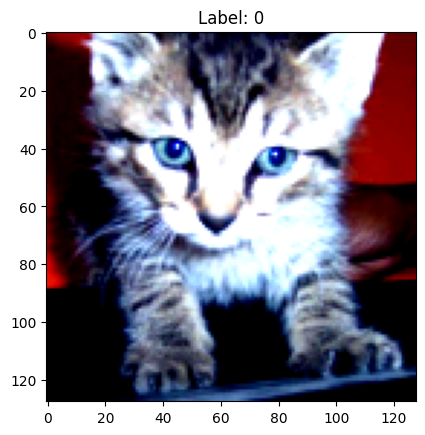

In [ ]:
images, labels = next(iter(train_dataloader))
img = images[0].permute(1,2,0) * 0.5 + 0.5     # rearranges the dimensions to (128, 128, 3). Kinda of rescaling to (0,1)
plt.imshow(img)
plt.title(f"Label: {labels[0].item()}")
plt.show()


# Loading Pretrained ResNet18 Model

**Used pretrained ResNet18 and replaced the final layer to predict 2 classes: cat or dog.**

In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Replace final layer for 2 classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 118MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# Defining Loss Function And Optimizer

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(),lr = 0.0001)

In [ ]:
# Random Check

print("Classes:", full_dataset.classes)

labels_list = []
for _, label in train_dataloader:
    labels_list.extend(label.tolist())
    break

print("Sample labels:", labels_list[:20])
print("Unique labels:", set(labels_list))


Classes: ['cats', 'dogs']
Sample labels: [0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0]
Unique labels: {0, 1}


# Training With Early Stopping

In [ ]:
epochs = 15
best_val_acc = 0.0
best_model_wts = None
patience = 3  # stop if val acc doesn't improve for 3 epochs
trigger_times = 0

for epoch in range(epochs):
    # ---- TRAIN ----
    model.train()
    train_loss = 0.0

    for images, labels in train_dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_dataloader)

    # ---- VALIDATION ----
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

    # ---- EARLY STOPPING ----
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = model.state_dict()  # saving best weights
        trigger_times = 0
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# ---- LOADING BEST MODEL ----
model.load_state_dict(best_model_wts)
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")


Epoch 1/15 | Train Loss: 0.1716 | Val Acc: 96.00%
Epoch 2/15 | Train Loss: 0.0470 | Val Acc: 95.88%
Epoch 3/15 | Train Loss: 0.0236 | Val Acc: 96.13%
Epoch 4/15 | Train Loss: 0.0055 | Val Acc: 96.44%
Epoch 5/15 | Train Loss: 0.0116 | Val Acc: 95.44%
Epoch 6/15 | Train Loss: 0.0279 | Val Acc: 95.75%
Epoch 7/15 | Train Loss: 0.0146 | Val Acc: 95.88%
Early stopping at epoch 7
Best Validation Accuracy: 96.44%


**Trained the model with early stopping to prevent overfitting and saved the best model based on validation accuracy.**
**Calculated the final validation accuracy of the trained model which came out at 97.50%.**

# Loading Test Dataset

In [ ]:
test_dir = "/kaggle/input/cat-and-dog/test_set/test_set"

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=test_transforms
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)


# Final Evaluation

In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")

# Conclusion

**In this notebook,I built a cats and dogs image classifier using transfer learning with ResNet-18. I fine-tuned the last layer for our two classes and used early stopping to keep the best model. After fixing the test data path, the model got 96.7% accuracy on unseen images.**
**Let me know if there are any improvements i can make to this notebook.**

# Visualization
**Checking to see if the model is working correctly**

In [ ]:
from PIL import Image

def predict_cat_or_dog(model, img_path):
    model.eval()
    image = Image.open(img_path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize((128,128)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
    ])
    img_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        _, pred = torch.max(outputs, 1)

    return full_dataset.classes[pred.item()]



In [ ]:
# Example usage:
img_path = "/kaggle/input/cat-and-dog/test_set/test_set/cats/cat.4555.jpg"
print(predict_cat_or_dog(model, img_path))

img = Image.open(img_path)
plt.imshow(img)
plt.axis("off")
plt.show()
